Paquetes necesarios

Podremos hacer uso del mismo *environment* de la primera práctica, aunque en ocasiones pedirá instalar Pillow

In [2]:
import cv2  
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image, ImageDraw, ImageFont

In [3]:
img = cv2.imread('mandril.jpg')
gris = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
canny = cv2.Canny(gris, 100, 200) #prueba a jugar con umbrales (entre 0 y 255)

img2 = cv2.imread('logoulpgc.jpg')
gris2 = cv2.cvtColor(img2, cv2.COLOR_BGR2GRAY)
canny2 = cv2.Canny(gris2, 100, 200) #prueba a jugar con umbrales (entre 0 y 255)

TAREA: Realiza la cuenta de píxeles blancos por filas (en lugar de por columnas). Determina el valor máximo de píxeles blancos para filas, maxfil, mostrando el número de filas y sus respectivas posiciones, con un número de píxeles blancos mayor o igual que 0.90*maxfil. Resalta con alguna primitiva gráfica en la imagen de Canny las filas que cumplen dicha condición.

Valor máximo de píxeles blancos (maxfil): 220.0
Fila(s) con el valor máximo: [12]
Número de filas que cumplen la condición (>= 0.90*maxfil): 7
Filas, número de píxeles blancos y porcentaje de blanco:
Fila 6: 203.0 píxeles (0.396484375)
Fila 12: 220.0 píxeles (0.4296875)
Fila 15: 204.0 píxeles (0.3984375)
Fila 20: 200.0 píxeles (0.390625)
Fila 21: 201.0 píxeles (0.392578125)
Fila 88: 199.0 píxeles (0.388671875)
Fila 100: 212.0 píxeles (0.4140625)


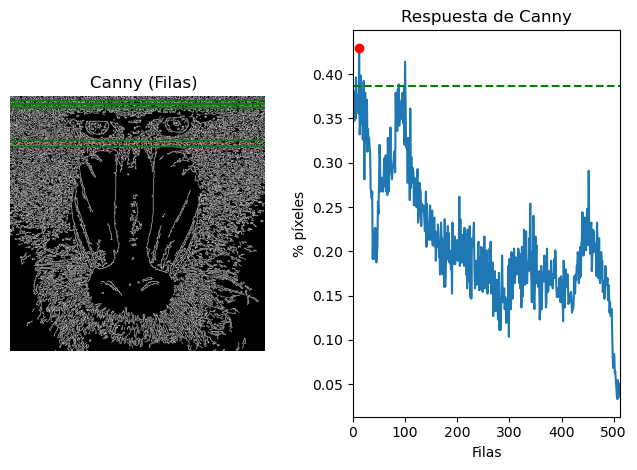

In [3]:
# Suma los valores de los píxeles por fila (dimensión 1)
row_counts = cv2.reduce(canny, 1, cv2.REDUCE_SUM, dtype=cv2.CV_32SC1) #Suma los valores de las filas (solo hay 255 o 0)

# Normaliza en base al número de columnas, segundo valor devuelto por shape, y al valor máximo del píxel (255)
rows = row_counts.flatten() / (255 * canny.shape[1]) #porcentaje de pixeles blancos por fila

row_pixels = row_counts.flatten() / 255 #numero de pixeles en cada fila
maxfil = np.max(row_pixels) #maximo
max_posiciones = np.where(row_pixels == maxfil)[0] # posición del maximo
posiciones = np.where(row_pixels >= 0.90 * maxfil)[0] # posiciones de las filas con >0.9*maximo

print(f"Valor máximo de píxeles blancos (maxfil): {maxfil}")
print(f"Fila(s) con el valor máximo: {max_posiciones}")
print(f"Número de filas que cumplen la condición (>= 0.90*maxfil): {len(posiciones)}")
print("Filas, número de píxeles blancos y porcentaje de blanco:")
for pos in posiciones:
    print(f"Fila {pos}: {row_pixels[pos]} píxeles ({rows[pos]})")

# Muestra dicha cuenta gráficamente
plt.figure()
plt.subplot(1, 2, 1)
plt.axis("off")
plt.title("Canny (Filas)")
plt.imshow(canny, cmap='gray')
plt.hlines(posiciones, 0, canny.shape[1], colors='g', lw=1)

plt.subplot(1, 2, 2)
plt.title("Respuesta de Canny")
plt.xlabel("Filas")
plt.ylabel("% píxeles")
plt.plot(rows)
plt.axhline(0.90 * maxfil / canny.shape[1], color='g', ls='--')
plt.plot(max_posiciones, rows[max_posiciones], 'ro')
# Rango en x definido por las filas
plt.xlim([0, canny.shape[0]])
plt.tight_layout()
plt.show()


Valor máximo de píxeles blancos (maxfil): 143.0
Fila(s) con el valor máximo: [96]
Número de filas que cumplen la condición (>= 0.90*maxfil): 1
Filas, número de píxeles blancos y porcentaje de blanco:
Fila 96: 143.0 píxeles (0.30168776371308015)


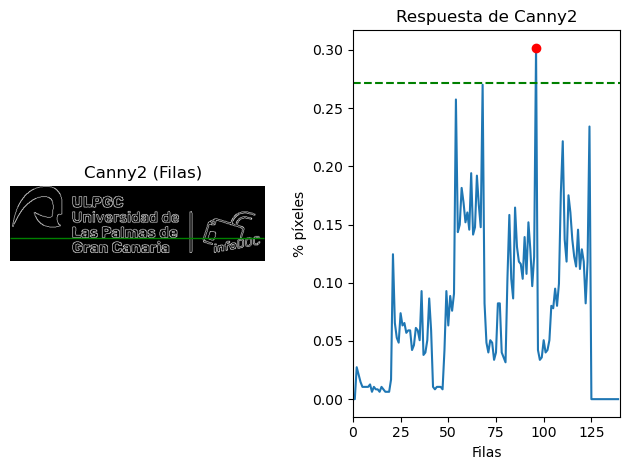

In [4]:
# Cuenta el número de píxeles blancos (255) por fila
# Suma los valores de los píxeles por fila (dimensión 1)
row_counts = cv2.reduce(canny2, 1, cv2.REDUCE_SUM, dtype=cv2.CV_32SC1) #produce una matriz filasx1

# Normaliza en base al número de columnas, segundo valor devuelto por shape, y al valor máximo del píxel (255)
# El resultado será la proporción de píxeles blancos por fila
rows = row_counts.flatten() / (255 * canny2.shape[1]) #flatten extrae los elementos y los aplana de filasx1 a una lista

# Cálculo del número real de píxeles blancos por fila y determinación de maxfil
row_pixels = row_counts.flatten() / 255
maxfil = np.max(row_pixels)
max_posiciones = np.where(row_pixels == maxfil)[0] #se pone el 0 porque si no es una tupla que estorba, no da el array directamente
posiciones = np.where(row_pixels >= 0.90 * maxfil)[0]

# Salida por consola
print(f"Valor máximo de píxeles blancos (maxfil): {maxfil}")
print(f"Fila(s) con el valor máximo: {max_posiciones}")
print(f"Número de filas que cumplen la condición (>= 0.90*maxfil): {len(posiciones)}")
print("Filas, número de píxeles blancos y porcentaje de blanco:")
for pos in posiciones:
    print(f"Fila {pos}: {row_pixels[pos]} píxeles ({rows[pos]})")

# Muestra dicha cuenta gráficamente
plt.figure()
plt.subplot(1, 2, 1)
plt.axis("off")
plt.title("Canny2 (Filas)")
plt.imshow(canny2, cmap='gray')
plt.hlines(posiciones, 0, canny2.shape[1], colors='g', lw=1)

plt.subplot(1, 2, 2)
plt.title("Respuesta de Canny2")
plt.xlabel("Filas")
plt.ylabel("% píxeles")
plt.plot(rows)
plt.axhline(0.90 * maxfil / canny2.shape[1], color='g', ls='--')
plt.plot(max_posiciones, rows[max_posiciones], 'ro')
# Rango en x definido por las filas
plt.xlim([0, canny2.shape[0]])
plt.tight_layout()
plt.show()


TAREA: Aplica umbralizado a la imagen resultante de Sobel (convertida a 8 bits), y posteriormente realiza el conteo por filas y columnas similar al realizado en el ejemplo con la salida de Canny de píxeles no nulos. Calcula el valor máximo de la cuenta por filas y columnas, y determina las filas y columnas por encima del 0.90*máximo. Remarca con alguna primitiva gráfica dichas filas y columnas sobre la imagen del mandril. Visualiza los resultados obtenidos para la imagen (o una de tu elección) con Canny y Sobe tras umbralizar ¿Cómo se comparan los resultados obtenidos a partir de Sobel y Canny?

COLUMNAS DESTACADAS (>=90% de 220.0 pixeles en la columna [104])
  - Columna 104: 220.0 píxeles | 0.4296875% del alto
  - Columna 105: 203.0 píxeles | 0.396484375% del alto
  - Columna 127: 214.0 píxeles | 0.41796875% del alto
  - Columna 288: 203.0 píxeles | 0.396484375% del alto

FILAS DESTACADAS (>=90% de 247.0 pixeles en la fila [ 4 24])
  - Fila    1: 224.0 píxeles | 0.4375% del ancho
  - Fila    2: 239.0 píxeles | 0.466796875% del ancho
  - Fila    3: 246.0 píxeles | 0.48046875% del ancho
  - Fila    4: 247.0 píxeles | 0.482421875% del ancho
  - Fila    5: 240.0 píxeles | 0.46875% del ancho
  - Fila    6: 246.0 píxeles | 0.48046875% del ancho
  - Fila    7: 239.0 píxeles | 0.466796875% del ancho
  - Fila    8: 238.0 píxeles | 0.46484375% del ancho
  - Fila    20: 244.0 píxeles | 0.4765625% del ancho
  - Fila    23: 223.0 píxeles | 0.435546875% del ancho
  - Fila    24: 247.0 píxeles | 0.482421875% del ancho
  - Fila    81: 224.0 píxeles | 0.4375% del ancho
  - Fila    82: 234.0 p

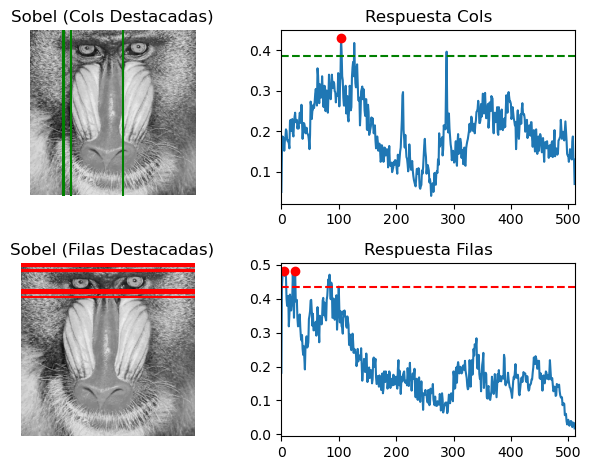

COLUMNAS DESTACADAS (>=90% de 138.0 pixeles en la columna [104])
  - Columna 92: 125.0 píxeles | 0.244140625% del alto
  - Columna 104: 138.0 píxeles | 0.26953125% del alto
  - Columna 119: 128.0 píxeles | 0.25% del alto

FILAS DESTACADAS (>=90% de 184.0 pixeles en la fila [24])
  - Fila    6: 172.0 píxeles | 0.3359375% del ancho
  - Fila    8: 170.0 píxeles | 0.33203125% del ancho
  - Fila    20: 168.0 píxeles | 0.328125% del ancho
  - Fila    24: 184.0 píxeles | 0.359375% del ancho
  - Fila    100: 166.0 píxeles | 0.32421875% del ancho


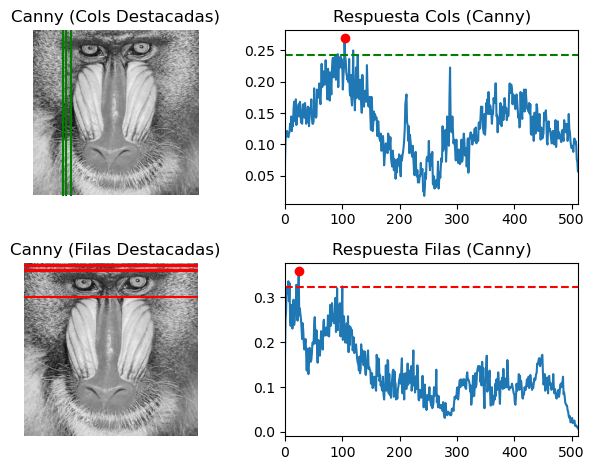

In [ ]:

ggris = cv2.GaussianBlur(gris, (3, 3), 0) #elimina el ruido de alta frecuencia antes de calcular las derivadas
sobel8x = cv2.convertScaleAbs(cv2.Sobel(ggris, cv2.CV_64F, 1, 0)) # le aplica la matriz x de sobel para bordes verticales, y se reajustan los valores y se le hace el valor absoluto
sobel8y = cv2.convertScaleAbs(cv2.Sobel(ggris, cv2.CV_64F, 0, 1)) # le aplica a la matriz de máscara para bordes horizontales, y se reajusta los valores y se le hace el valor absoluto
sobel8 = cv2.add(sobel8x, sobel8y) # se suman ambos valores

valorUmbral = 130
_, imagenUmbralizada = cv2.threshold(sobel8, valorUmbral, 255, cv2.THRESH_BINARY) # se le aplica a sobel8 los valores umbrales,
# pixeles mayores de 130 se comvierten en 255, los demás en 0

# Análisis de las columnas
col_counts = cv2.reduce(imagenUmbralizada, 0, cv2.REDUCE_SUM, dtype=cv2.CV_32SC1)[0] #suma los valores de las columnas y lo guarda en un array con el [0]
cols = col_counts / (255 * imagenUmbralizada.shape[0]) #divide por el numero de filas  y por el 255 para saber cuantos porcentaje entre 0-1 hay
col_pixels = col_counts / 255 #consigue los pixeles por columna

maxcol = np.max(col_pixels) # coge el maximo del array
max_posiciones_cols = np.where(col_pixels == maxcol)[0] #busca los índices donde se alcanza el valor máximo de los pixeles
posiciones_cols = np.where(col_pixels >= 0.90 * maxcol)[0] #busca los índices donde se alcanza el valor >90 % de los pixeles

# 3. Análisis por columnas
row_counts = cv2.reduce(imagenUmbralizada, 1, cv2.REDUCE_SUM, dtype=cv2.CV_32SC1).flatten() #suma los valores de las columnas y lo guarda en un array con el [0]
rows = row_counts / (255 * imagenUmbralizada.shape[1]) #divide por el numero de filas  y por el 255 para saber cuantos porcentaje entre 0-1 hay
row_pixels = row_counts / 255 #consigue los pixeles por columna

maxfil = np.max(row_pixels) # coge el maximo del array
max_posiciones_fils = np.where(row_pixels == maxfil)[0] #busca los índices donde se alcanza el valor máximo de los pixeles
posiciones_fils = np.where(row_pixels >= 0.90 * maxfil)[0] #busca los índices donde se alcanza el valor >90 % de los pixeles

print(f"COLUMNAS DESTACADAS (>=90% de {maxcol} pixeles en la columna {max_posiciones_cols})")
for pos in posiciones_cols:
    print(f"  - Columna {pos}: {col_pixels[pos]} píxeles | {cols[pos]}% del alto")

print(f"\nFILAS DESTACADAS (>=90% de {maxfil} pixeles en la fila {max_posiciones_fils})")
for pos in posiciones_fils:
    print(f"  - Fila    {pos}: {row_pixels[pos]} píxeles | {rows[pos]}% del ancho")

plt.subplot(2, 2, 1)
plt.title("Sobel (Cols Destacadas)")
plt.imshow(gris, cmap='gray')
plt.vlines(posiciones_cols, 0, gris.shape[0], colors='g')
plt.axis("off")

plt.subplot(2, 2, 2)
plt.title("Respuesta Cols")
plt.plot(cols)
plt.axhline(0.90 * maxcol / imagenUmbralizada.shape[0], color='g', ls='--') # linea verde para las lineas señaladas
plt.plot(max_posiciones_cols, cols[max_posiciones_cols], 'ro')
plt.xlim([0, imagenUmbralizada.shape[1]])

plt.subplot(2, 2, 3)
plt.title("Sobel (Filas Destacadas)")
plt.imshow(gris, cmap='gray')
plt.hlines(posiciones_fils, 0, gris.shape[1], colors='r')
plt.axis("off")

plt.subplot(2, 2, 4)
plt.title("Respuesta Filas")
plt.plot(rows)
plt.axhline(0.90 * maxfil / imagenUmbralizada.shape[1], color='r', ls='--')
plt.plot(max_posiciones_fils, rows[max_posiciones_fils], 'ro')
plt.xlim([0, imagenUmbralizada.shape[0]])

plt.tight_layout()
plt.show()

ggris = cv2.GaussianBlur(gris, (3, 3), 0) # elimina el ruido antes de calcular gradientes
canny = cv2.Canny(ggris, 100, 200) # aplica Canny con sus umbrales interno (100 y 200)

# 2. Análisis por columnas
col_counts = cv2.reduce(canny, 0, cv2.REDUCE_SUM, dtype=cv2.CV_32SC1)[0] # suma valores por columna
cols = col_counts / (255 * canny.shape[0]) # porcentaje (0-1) respecto al alto
col_pixels = col_counts / 255 # recuento de píxeles de borde por columna

maxcol = np.max(col_pixels) # valor máximo del array
max_posiciones_cols = np.where(col_pixels == maxcol)[0] # índice con valor máximo
posiciones_cols = np.where(col_pixels >= 0.90 * maxcol)[0] # índice >= 90% del máximo

# 3. Análisis por FILAS
row_counts = cv2.reduce(canny, 1, cv2.REDUCE_SUM, dtype=cv2.CV_32SC1).flatten() # suma valores por fila y aplana
rows = row_counts / (255 * canny.shape[1]) # porcentaje (0-1) respecto al ancho
row_pixels = row_counts / 255 # recuento de píxeles de borde por fila

maxfil = np.max(row_pixels) # valor máximo del array
max_posiciones_fils = np.where(row_pixels == maxfil)[0] # índice con valor máximo
posiciones_fils = np.where(row_pixels >= 0.90 * maxfil)[0] # índice>= 90% del máximo

# Salida por consola
print(f"COLUMNAS DESTACADAS (>=90% de {maxcol} pixeles en la columna {max_posiciones_cols})")
for pos in posiciones_cols:
    print(f"  - Columna {pos}: {col_pixels[pos]} píxeles | {cols[pos]}% del alto")

print(f"\nFILAS DESTACADAS (>=90% de {maxfil} pixeles en la fila {max_posiciones_fils})")
for pos in posiciones_fils:
    print(f"  - Fila    {pos}: {row_pixels[pos]} píxeles | {rows[pos]}% del ancho")

plt.subplot(2, 2, 1)
plt.title("Canny (Cols Destacadas)")
plt.imshow(gris, cmap='gray')
plt.vlines(posiciones_cols, 0, gris.shape[0], colors='g')
plt.axis("off")

plt.subplot(2, 2, 2)
plt.title("Respuesta Cols (Canny)")
plt.plot(cols)
plt.axhline(0.90 * maxcol / canny.shape[0], color='g', ls='--')
plt.plot(max_posiciones_cols, cols[max_posiciones_cols], 'ro')
plt.xlim([0, canny.shape[1]])

plt.subplot(2, 2, 3)
plt.title("Canny (Filas Destacadas)")
plt.imshow(gris, cmap='gray')
plt.hlines(posiciones_fils, 0, gris.shape[1], colors='r')
plt.axis("off")

plt.subplot(2, 2, 4)
plt.title("Respuesta Filas (Canny)")
plt.plot(rows)
plt.axhline(0.90 * maxfil / canny.shape[1], color='r', ls='--')
plt.plot(max_posiciones_fils, rows[max_posiciones_fils], 'ro')
plt.xlim([0, canny.shape[0]])

plt.tight_layout()
plt.show()

Diferencia de imágenes

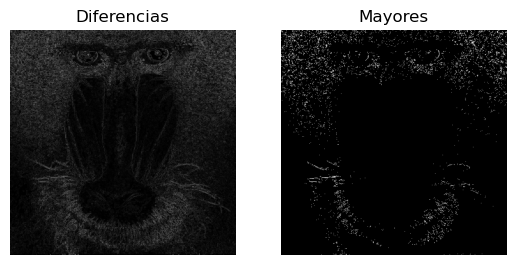

In [52]:
#Calcula la diferencia entre dos imágenes
#Utiliza la imagen original y la obtenida tras aplicar la gaussiana (creada en la celda dedicada a Sobel)
dif = cv2.absdiff(gris, ggris)

#Visualiza
plt.figure()
plt.subplot(1, 2, 1)
plt.title("Diferencias")
plt.axis("off")
plt.imshow(dif, cmap='gray') 

#Zonas de mayor diferencia tras aplicar umbral
res, imgdif = cv2.threshold(dif, 30, 255, cv2.THRESH_BINARY)
#Visualiza
plt.subplot(1, 2, 2)
plt.title("Mayores")
plt.axis("off")
plt.imshow(imgdif, cmap='gray') 
plt.show()


TAREA: Tras ver los vídeos [My little piece of privacy](https://www.niklasroy.com/project/88/my-little-piece-of-privacy), [Messa di voce](https://youtu.be/GfoqiyB1ndE?feature=shared) y [Virtual air guitar](https://youtu.be/FIAmyoEpV5c?feature=shared) proponer un demostrador reinterpretando la parte de procesamiento de la imagen, tomando como punto de partida alguna de dichas instalaciones.

In [ ]:
row_counts = cv2.reduce(canny, 1, cv2.REDUCE_SUM, dtype=cv2.CV_32SC1) #produce una matriz filasx1
vid = cv2.VideoCapture(0)

#Marca de inicio
disponible = 0 
while(True):      
    # fotograma a fotograma
    ret, frame = vid.read()

    if ret:
        if disponible > 0:
            dif = cv2.absdiff(frame, pframe)  
            ggris = cv2.GaussianBlur(dif, (3, 3), 0) # elimina el ruido antes de calcular gradientes
            canny3 = cv2.Canny(ggris, 100, 200) # aplica Canny con sus umbrales interno (100 y 200)

            col_counts = cv2.reduce(canny3, 0, cv2.REDUCE_SUM, dtype=cv2.CV_32SC1)[0] # suma valores por columna
            col_pixels = col_counts / 255 # recuento de píxeles de borde por columna

            maxcol = np.max(col_pixels) # valor máximo del array
            max_posiciones_cols = np.where(col_pixels == maxcol)[0] # índice con valor máximo
            
            # Muestra resultado
            cv2.imshow('Diferencia', dif)    
        else:
            disponible = 1

        #Copia fotograma actual para la diferencia en el siguiente forograma
        pframe = frame.copy()
    # Detenemos pulsado ESC
    if cv2.waitKey(20) == 27:
        print(col_pixels)
        break
  
# Libera el objeto de captura
vid.release()
# Destruye ventanas
cv2.destroyAllWindows()

In [4]:
vid = cv2.VideoCapture(0)
# Cargar la imagen del OVNI y redimensionar
ovni = cv2.imread('ovni.png')
ovni = cv2.resize(ovni, (250, 150))
h_ovni, w_ovni, _ = ovni.shape

#Marca de inicio
disponible = 0 
while(True):      
    # fotograma a fotograma
    ret, frame = vid.read()

    if ret:
        if disponible > 0:
            dif = cv2.absdiff(frame, pframe)
            gris = cv2.cvtColor(dif, cv2.COLOR_BGR2GRAY)
            ggris = cv2.GaussianBlur(gris, (3, 3), 0) #elimina el ruido de alta frecuencia antes de calcular las derivadas
            sobel8x = cv2.convertScaleAbs(cv2.Sobel(ggris, cv2.CV_64F, 1, 0)) # le aplica la matriz x de sobel para bordes verticales, y se reajustan los valores y se le hace el valor absoluto      
            # Muestra resultado
            _, bordesverticales = cv2.threshold(sobel8x, 30, 255, cv2.THRESH_BINARY) # se le aplica a sobel8 los valores umbrales,
            # pixeles mayores de 130 se comvierten en 255, los demás en 0

            # Análisis de las columnas
            col_counts = cv2.reduce(bordesverticales, 0, cv2.REDUCE_SUM, dtype=cv2.CV_32SC1)[0] #suma los valores de las columnas y lo guarda en un array con el [0]
            col_pixels = col_counts / 255 #consigue los pixeles por columna
            cv2.imshow('Diferencia', dif)    
            umbrales_movimiento = np.where(col_pixels > 12)[0]

            if len(umbrales_movimiento) > 0:
                col_izquierda = umbrales_movimiento[0]
                col_derecha = umbrales_movimiento[-1]
                # Posición de la columna azul (centro)
                centro_x = int((col_izquierda + col_derecha) / 2)
                # --- PEGAR OVNI TRANSPARENTE EN EL CENTRO ---
                x1 = centro_x - (w_ovni // 2)
                x2 = x1 + w_ovni
                if x1 >= 0 and x2 <= frame.shape[1]: #x1 es el limite izquierdo del ovni, x2 es el limite derecho del ovni si el x1 esta por la izq de la pantalla dará error, lo mismo con x2 menor que el ancho de la pantalla (parte derecha)
                # 1. Recorte de la zona donde irá el OVNI
                    roi = frame[0:h_ovni, x1:x2]

                    # 2. Detectar píxeles que NO son blancos en el OVNI
                    mask_ovni = cv2.cvtColor(ovni, cv2.COLOR_BGR2GRAY) < 240
                    mask_3d = cv2.merge([mask_ovni, mask_ovni, mask_ovni])

                    # 3. Copiar solo la nave sobre el vídeo
                    roi[mask_3d] = ovni[mask_3d]
            cv2.imshow('Deteccion OVNI', frame)
        else:
            disponible = 1

    #Copia fotograma actual para la diferencia en el siguiente forograma
    pframe = frame.copy()
    # Detenemos pulsado ESC
    if cv2.waitKey(20) == 27:
        break
  
# Libera el objeto de captura
vid.release()
# Destruye ventanas
cv2.destroyAllWindows()